# GABAB IPSP Area – Sanity Check (Figure 4)

Plots every Gabazine trace (ISI = 300 ms, all pathways) used to compute the
GABAB area metric in Figure 4.  For each trace the notebook:

1. Calls `calculate_GABAB_area` to get the signed integral of the negative component
2. Draws the raw trace (mV, offset so baseline ≈ 0)
3. **Shades the negative region** that is integrated (the GABAB IPSP)
4. **Annotates** the computed area value

Panels are grouped by **Pathway → Genotype** and sorted from most-negative
area to least-negative so outliers cluster at the left edge of each group.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
from analysis_utils import calculate_GABAB_area

%matplotlib inline

# ── global style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':      110,
    'font.size':       10,
    'axes.titlesize':  10,
    'axes.labelsize':  9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

In [2]:
# ── Load the E/I traces pickle ────────────────────────────────────────────────
EI_PKL = 'paper_data/E_I_data/E_I_traces_for_plotting.pkl'

with open(EI_PKL, 'rb') as f:
    ei_df = pickle.load(f)

print(f'Loaded {len(ei_df)} total rows.')

Loaded 573 total rows.


In [3]:
# ── Filter ISI=300 rows with a Gabazine trace; compute GABAB area ─────────────
SAMPLING_RATE = 20_000  # Hz

isi300 = ei_df[ei_df['ISI'] == 300].copy()

def get_gabazine_trace(row):
    """Return a numpy array for the Gabazine trace, or None if absent."""
    for col in ('Gabazine_Trace', 'gabazine_Trace'):
        val = row.get(col, None)
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            arr = np.asarray(val, dtype=float).flatten()
            if arr.size > 0:
                return arr
    return None

rows_with_trace = []
for _, row in isi300.iterrows():
    arr = get_gabazine_trace(row)
    if arr is not None:
        rows_with_trace.append({
            'Cell_ID':  str(row['Cell_ID']),
            'Genotype': row['Genotype'],
            'Pathway':  row['Pathway'],
            'trace':    arr,
            'area':     calculate_GABAB_area(arr, sampling_rate=SAMPLING_RATE),
        })

plot_df = pd.DataFrame(rows_with_trace)

print(f'Rows with Gabazine trace (ISI=300): {len(plot_df)}')
print(plot_df.groupby(['Pathway', 'Genotype']).size().rename('n').to_frame())

Rows with Gabazine trace (ISI=300): 154
                                n
Pathway              Genotype    
Basal_Stratum_Oriens GNB1      10
                     WT        12
Perforant            GNB1      34
                     WT        33
Schaffer             GNB1      33
                     WT        32


In [4]:
# ── Plotting helper ───────────────────────────────────────────────────────────

WT_COLOR   = '#2166ac'   # blue
GNB1_COLOR = '#d6604d'   # red-orange

def plot_trace_with_gabab_area(ax, trace, area, cell_id, genotype,
                               sampling_rate=20_000):
    """Draw one Gabazine trace with the GABAB area shaded."""
    dt_ms = 1000.0 / sampling_rate
    t_ms  = np.arange(len(trace)) * dt_ms

    color = WT_COLOR if genotype == 'WT' else GNB1_COLOR

    # raw trace
    ax.plot(t_ms, trace, lw=1.2, color=color, alpha=0.9)

    # shade the negative component
    ax.fill_between(t_ms, trace, 0,
                    where=(trace < 0),
                    color=color, alpha=0.30)

    # zero reference
    ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5)

    # area annotation — top-right corner
    ax.text(0.97, 0.97,
            f'A = {area:.4f} mV·s',
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=8, color='k',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, lw=0))

    # cell-ID title
    ax.set_title(cell_id, fontsize=9, pad=3)
    ax.set_xlim(t_ms[0], t_ms[-1])
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.set_ylabel('mV', fontsize=8)

/var/folders/w4/_c8ps64n6cxg0m9hl_lh3jgr0000gn/T/ipykernel_89848/2585424308.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


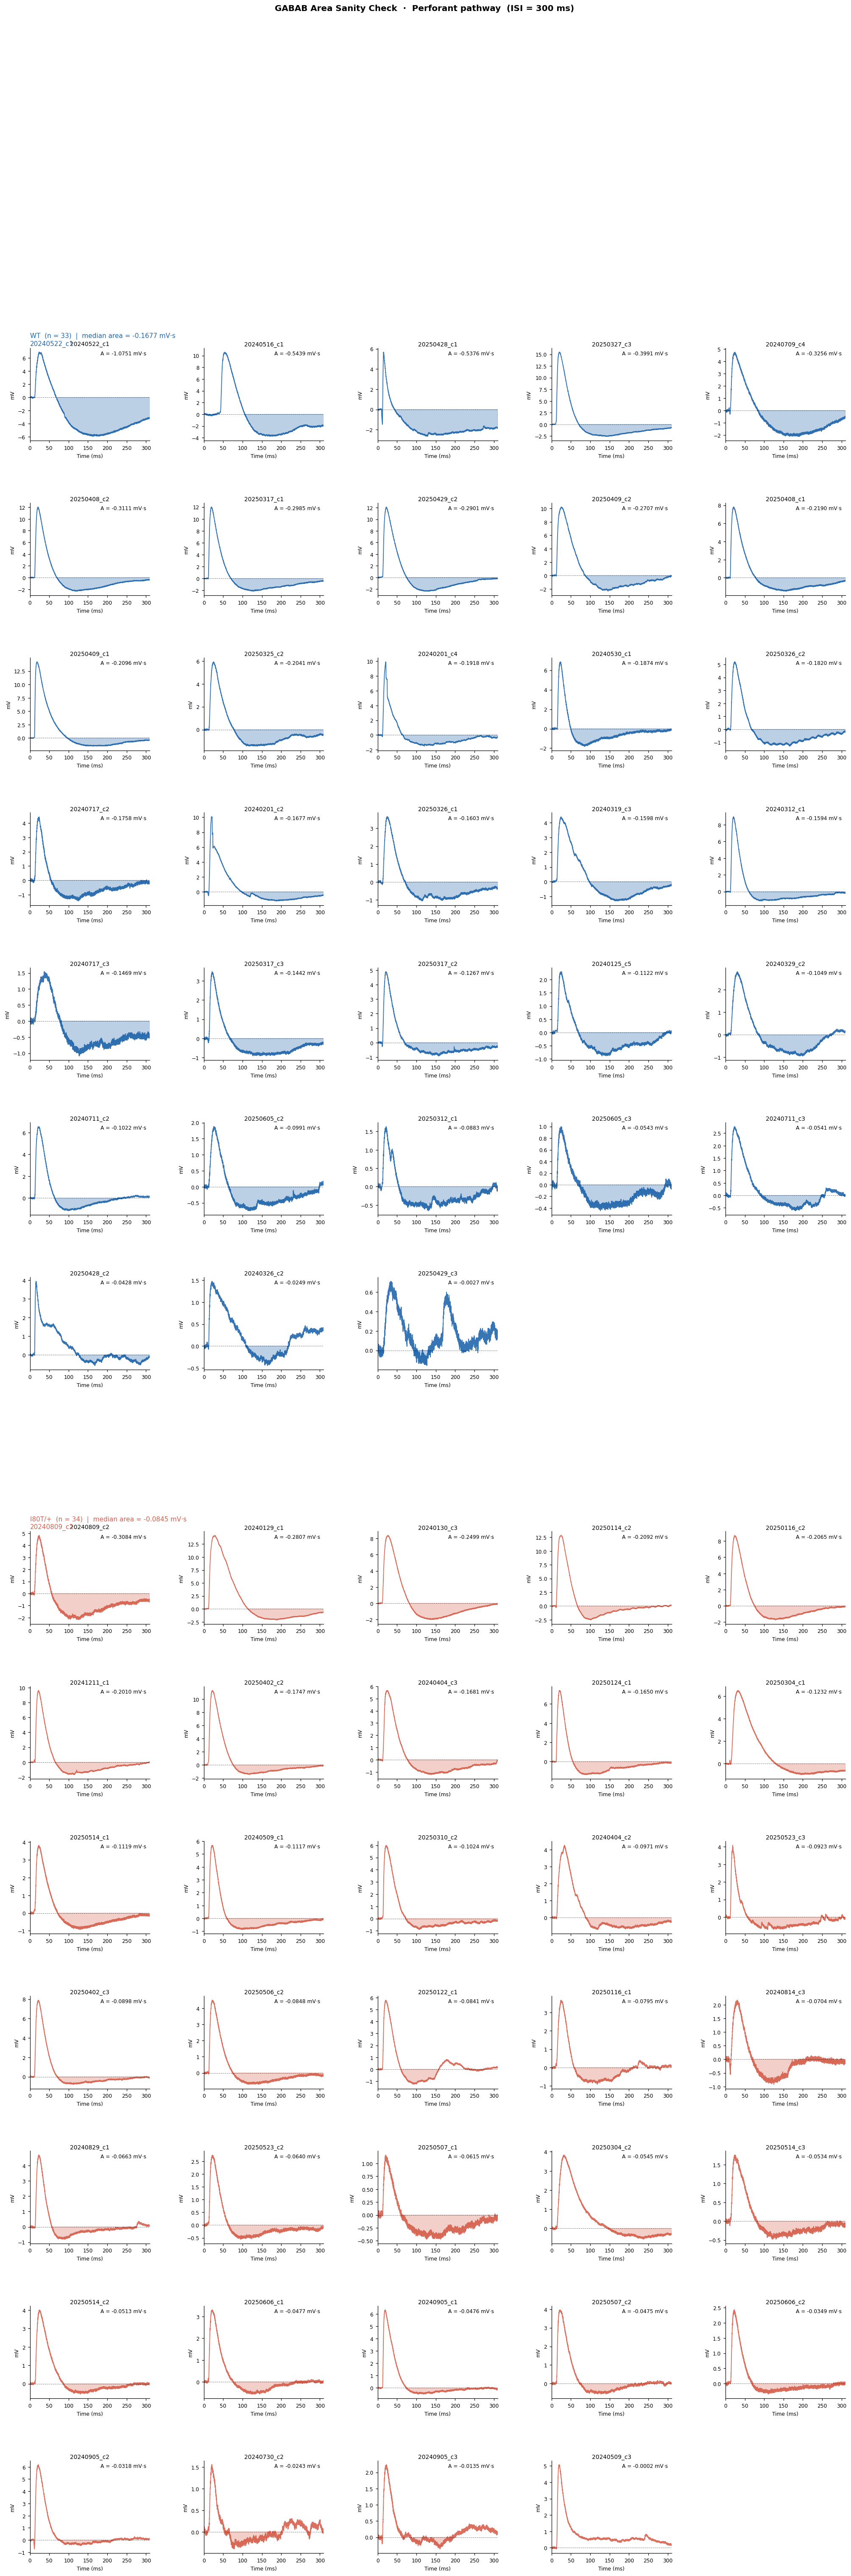

[Perforant] Plotted 67 traces (WT = 33, GNB1 = 34)



/var/folders/w4/_c8ps64n6cxg0m9hl_lh3jgr0000gn/T/ipykernel_89848/2585424308.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


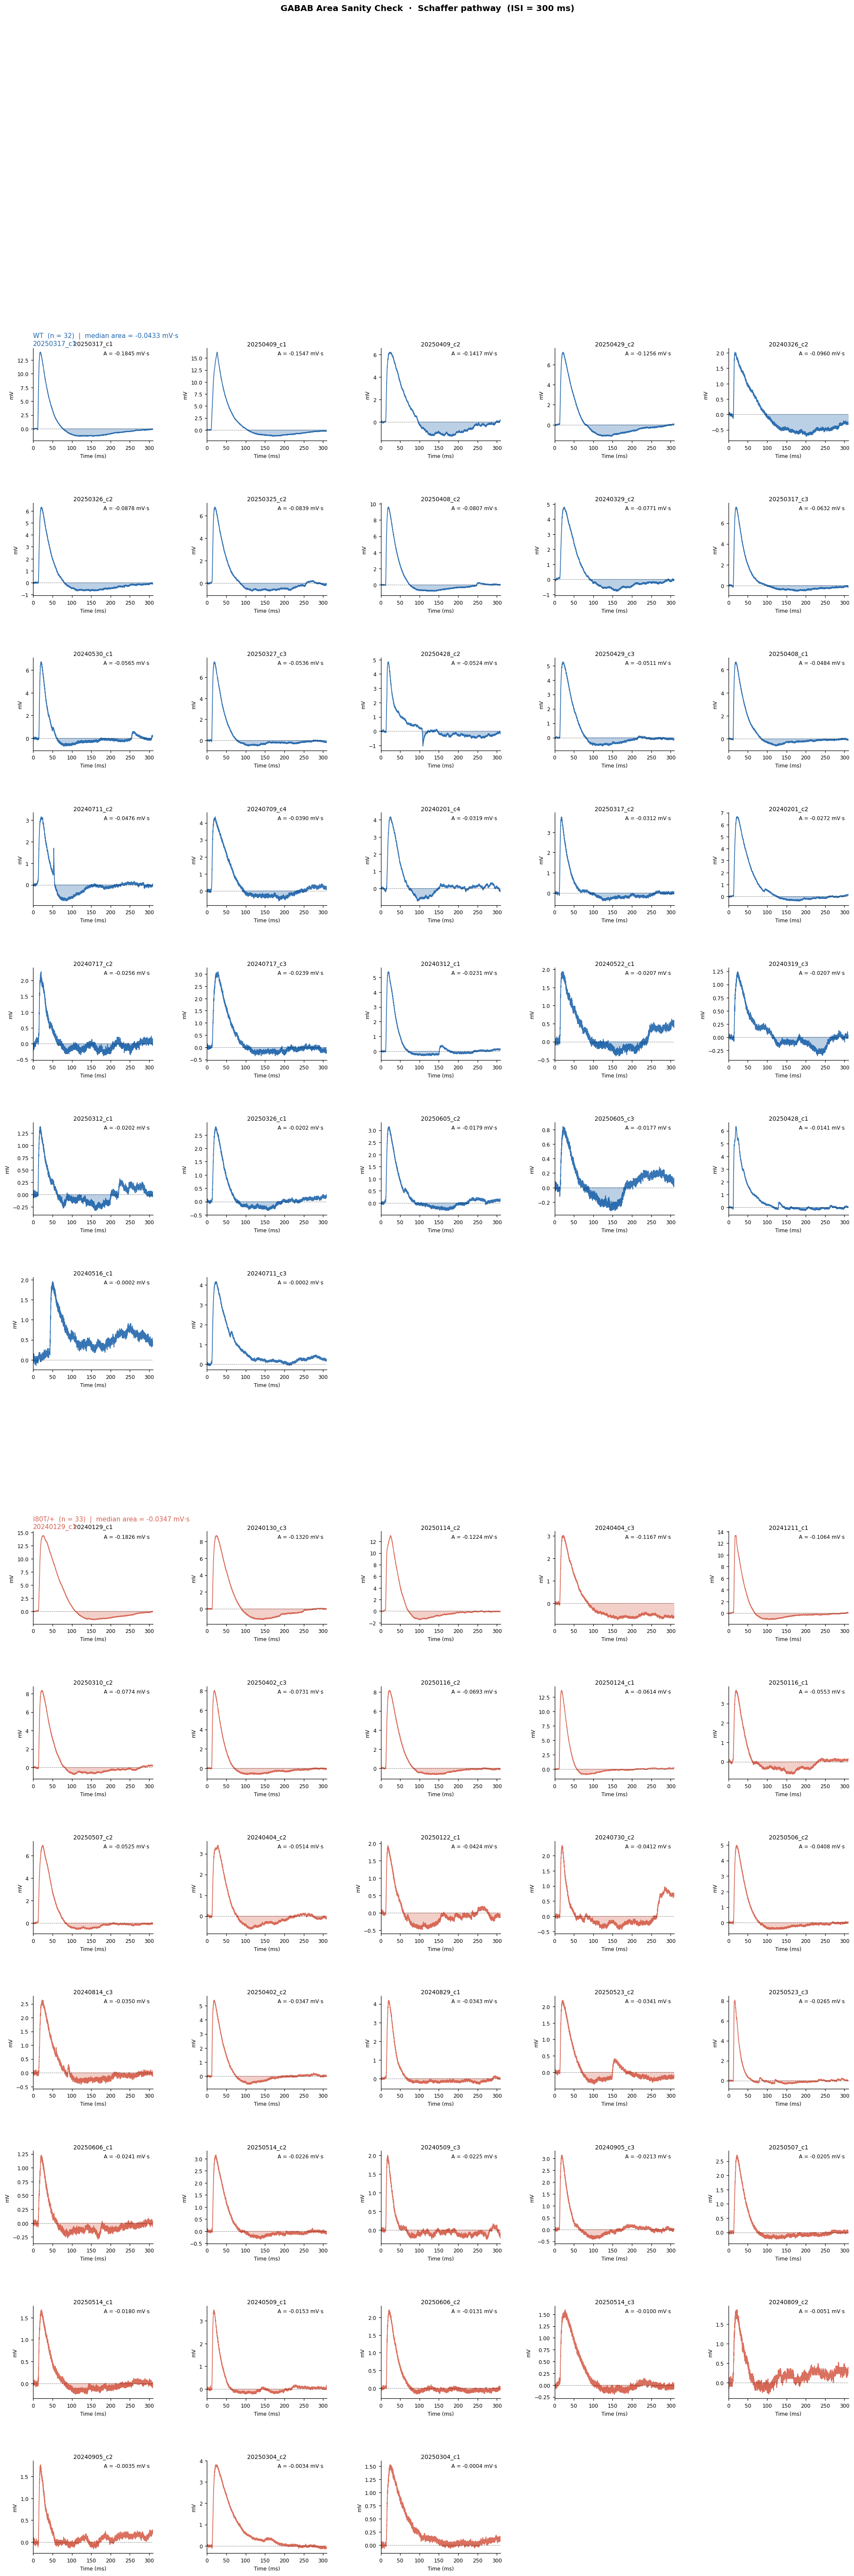

[Schaffer] Plotted 65 traces (WT = 32, GNB1 = 33)



/var/folders/w4/_c8ps64n6cxg0m9hl_lh3jgr0000gn/T/ipykernel_89848/2585424308.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


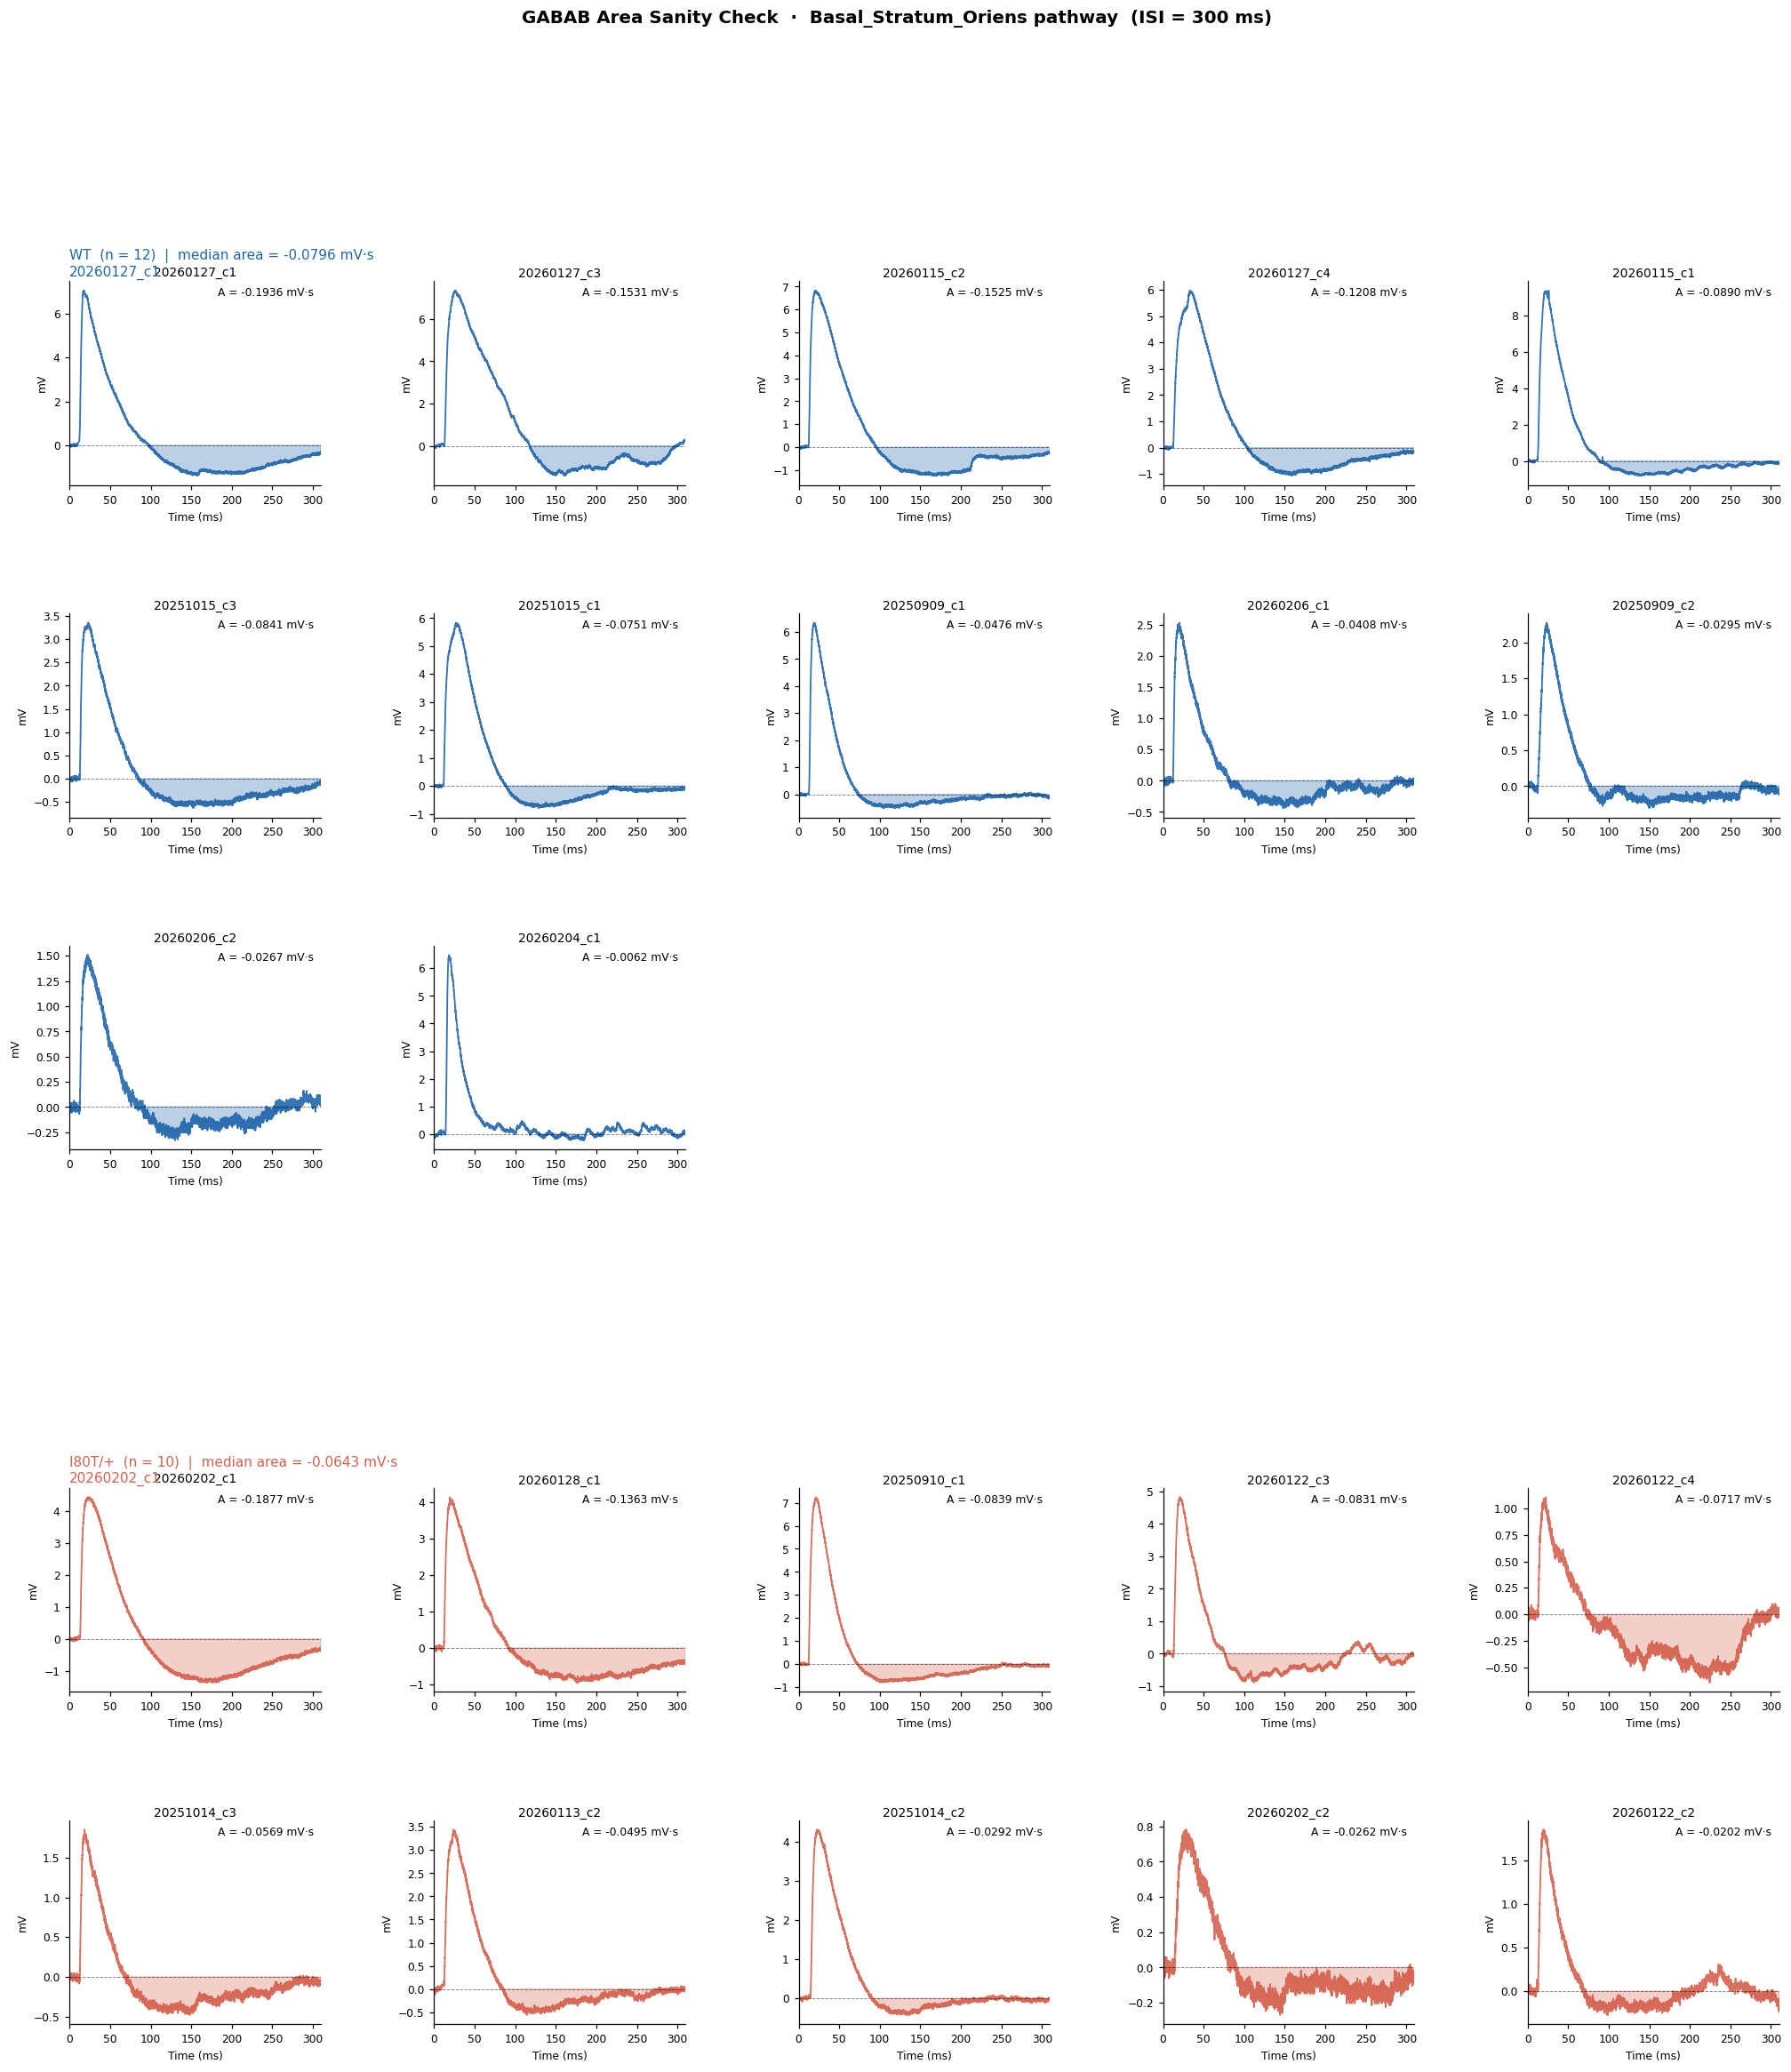

[Basal_Stratum_Oriens] Plotted 22 traces (WT = 12, GNB1 = 10)



In [5]:
# ── Main sanity-check loop: one figure per Pathway ────────────────────────────
#
# Layout: genotype rows (WT on top, GNB1 on bottom).
# Within each genotype row the cells are arranged in a sub-grid of NCOLS columns
# and sorted by area (most negative first) so the biggest IPSP is always top-left.
#
# Panel size: 3.2 × 2.5 inches each → comfortably readable.

NCOLS       = 5      # panels per row — keep it wide but not cramped
PANEL_W     = 3.2    # inches per panel
PANEL_H     = 2.5    # inches per panel
HSPACE      = 0.70   # vertical space between panels (fraction of panel height)
WSPACE      = 0.45   # horizontal space between panels
GENO_GAP    = 0.40   # extra vertical gap between the two genotype blocks

PATHWAYS  = ['Perforant', 'Schaffer', 'Basal_Stratum_Oriens']
GENOTYPES = ['WT', 'GNB1']

for pathway in PATHWAYS:
    path_df = plot_df[plot_df['Pathway'] == pathway].copy()
    if path_df.empty:
        print(f'[{pathway}] No data – skipping.')
        continue

    # ── compute grid dimensions per genotype ──────────────────────────────
    geno_data = {}
    for g in GENOTYPES:
        sub = path_df[path_df['Genotype'] == g].sort_values('area')  # most-neg first
        nrows = int(np.ceil(len(sub) / NCOLS)) if len(sub) > 0 else 0
        geno_data[g] = {'df': sub, 'nrows': nrows, 'n': len(sub)}

    total_panel_rows = sum(gd['nrows'] for gd in geno_data.values())
    if total_panel_rows == 0:
        continue

    # ── figure size ───────────────────────────────────────────────────────
    fig_w = NCOLS * PANEL_W + (NCOLS - 1) * PANEL_W * WSPACE + 0.8
    # height = sum of panel rows * PANEL_H * (1 + HSPACE) + gap between geno blocks + title
    fig_h = (total_panel_rows * PANEL_H * (1 + HSPACE)
             + GENO_GAP * PANEL_H
             + 0.9)   # suptitle space

    fig = plt.figure(figsize=(fig_w, fig_h))
    fig.suptitle(
        f'GABAB Area Sanity Check  ·  {pathway} pathway  (ISI = 300 ms)',
        fontsize=13, fontweight='bold', y=1.0
    )

    # ── draw genotype blocks one after another ────────────────────────────
    # We use gridspec manually so we can control the vertical gap between
    # the WT block and the GNB1 block.
    # Strategy: build a flat list of (genotype, row_within_block, col) specs.

    # Total rows in the figure = WT_nrows + GNB1_nrows (+ 1 row worth of gap)
    wt_nrows  = geno_data['WT']['nrows']
    gnb_nrows = geno_data['GNB1']['nrows']

    # We embed a blank row between the two blocks for the gap.
    # GridSpec row heights: [1]*wt_nrows, [GENO_GAP], [1]*gnb_nrows
    height_ratios = ([1] * wt_nrows) + ([GENO_GAP] if (wt_nrows > 0 and gnb_nrows > 0) else []) + ([1] * gnb_nrows)
    total_gs_rows = len(height_ratios)

    gs = gridspec.GridSpec(
        total_gs_rows, NCOLS,
        figure=fig,
        hspace=HSPACE,
        wspace=WSPACE,
        height_ratios=height_ratios,
    )

    def draw_geno_block(geno, gs_row_start, sub_df, n_cells):
        """Draw all panels for one genotype, returns list of axes created."""
        color  = WT_COLOR if geno == 'WT' else GNB1_COLOR
        label  = 'I80T/+' if geno == 'GNB1' else geno
        median = sub_df['area'].median() if n_cells > 0 else float('nan')

        axes_created = []
        for ci, (_, row) in enumerate(sub_df.iterrows()):
            r_idx = gs_row_start + ci // NCOLS
            c_idx = ci % NCOLS
            ax = fig.add_subplot(gs[r_idx, c_idx])
            plot_trace_with_gabab_area(
                ax,
                trace        = row['trace'],
                area         = row['area'],
                cell_id      = row['Cell_ID'],
                genotype     = geno,
                sampling_rate = SAMPLING_RATE,
            )
            axes_created.append(ax)

        # hide any unused slots in the last sub-row
        nrows_block = int(np.ceil(n_cells / NCOLS)) if n_cells > 0 else 0
        for ci in range(n_cells, nrows_block * NCOLS):
            r_idx = gs_row_start + ci // NCOLS
            c_idx = ci % NCOLS
            ax = fig.add_subplot(gs[r_idx, c_idx])
            ax.axis('off')

        # add a genotype label above the first panel of this block
        if axes_created:
            axes_created[0].set_title(
                f'{label}  (n = {n_cells})  |  median area = {median:.4f} mV·s\n'
                + axes_created[0].get_title(),
                fontsize=10, color=color, pad=4, loc='left'
            )

    # draw WT block
    draw_geno_block('WT',   0,
                    geno_data['WT']['df'],
                    geno_data['WT']['n'])

    # draw GNB1 block (starts after WT rows + 1 gap row)
    gnb_start = wt_nrows + (1 if wt_nrows > 0 else 0)
    draw_geno_block('GNB1', gnb_start,
                    geno_data['GNB1']['df'],
                    geno_data['GNB1']['n'])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    print(f'[{pathway}] Plotted {len(path_df)} traces '
          f'(WT = {geno_data["WT"]["n"]}, GNB1 = {geno_data["GNB1"]["n"]})')
    print()

In [6]:
# ── Numerical summary table ───────────────────────────────────────────────────

summary = (
    plot_df
    .groupby(['Pathway', 'Genotype'])['area']
    .agg(['count', 'min', 'median', 'max', 'std'])
    .round(4)
    .rename(columns={'count': 'n',
                     'min':    'min (mV·s)',
                     'median': 'median (mV·s)',
                     'max':    'max (mV·s)',
                     'std':    'std (mV·s)'})
)
print('GABAB Area summary (all values in mV·s):')
print(summary.to_string())

GABAB Area summary (all values in mV·s):
                                n  min (mV·s)  median (mV·s)  max (mV·s)  std (mV·s)
Pathway              Genotype                                                       
Basal_Stratum_Oriens GNB1      10     -0.1877        -0.0643     -0.0202      0.0528
                     WT        12     -0.1936        -0.0796     -0.0062      0.0591
Perforant            GNB1      34     -0.3084        -0.0845     -0.0002      0.0776
                     WT        33     -1.0751        -0.1677     -0.0027      0.2003
Schaffer             GNB1      33     -0.1826        -0.0347     -0.0004      0.0427
                     WT        32     -0.1845        -0.0433     -0.0002      0.0456


In [7]:
# ── Outlier flag (area < mean − 2·SD within Pathway × Genotype) ──────────────

flagged = []
for (pathway, genotype), grp in plot_df.groupby(['Pathway', 'Genotype']):
    mu        = grp['area'].mean()
    sd        = grp['area'].std()
    threshold = mu - 2 * sd          # area is negative; outlier = very large magnitude
    outliers  = grp[grp['area'] < threshold]
    for _, r in outliers.iterrows():
        flagged.append({
            'Pathway':   pathway,
            'Genotype':  genotype,
            'Cell_ID':   r['Cell_ID'],
            'area':      round(r['area'], 4),
            'threshold': round(threshold, 4),
        })

if flagged:
    print('⚠️  Potential outliers (area < mean − 2·SD):')
    print(pd.DataFrame(flagged).to_string(index=False))
else:
    print('✓ No outliers detected (all areas within mean ± 2·SD).')

⚠️  Potential outliers (area < mean − 2·SD):
             Pathway Genotype     Cell_ID    area  threshold
Basal_Stratum_Oriens     GNB1 20260202_c1 -0.1877    -0.1801
           Perforant     GNB1 20240809_c2 -0.3084    -0.2614
           Perforant     GNB1 20240129_c1 -0.2807    -0.2614
           Perforant       WT 20240522_c1 -1.0751    -0.6178
            Schaffer     GNB1 20240129_c1 -0.1826    -0.1330
            Schaffer       WT 20250317_c1 -0.1845    -0.1454
            Schaffer       WT 20250409_c1 -0.1547    -0.1454


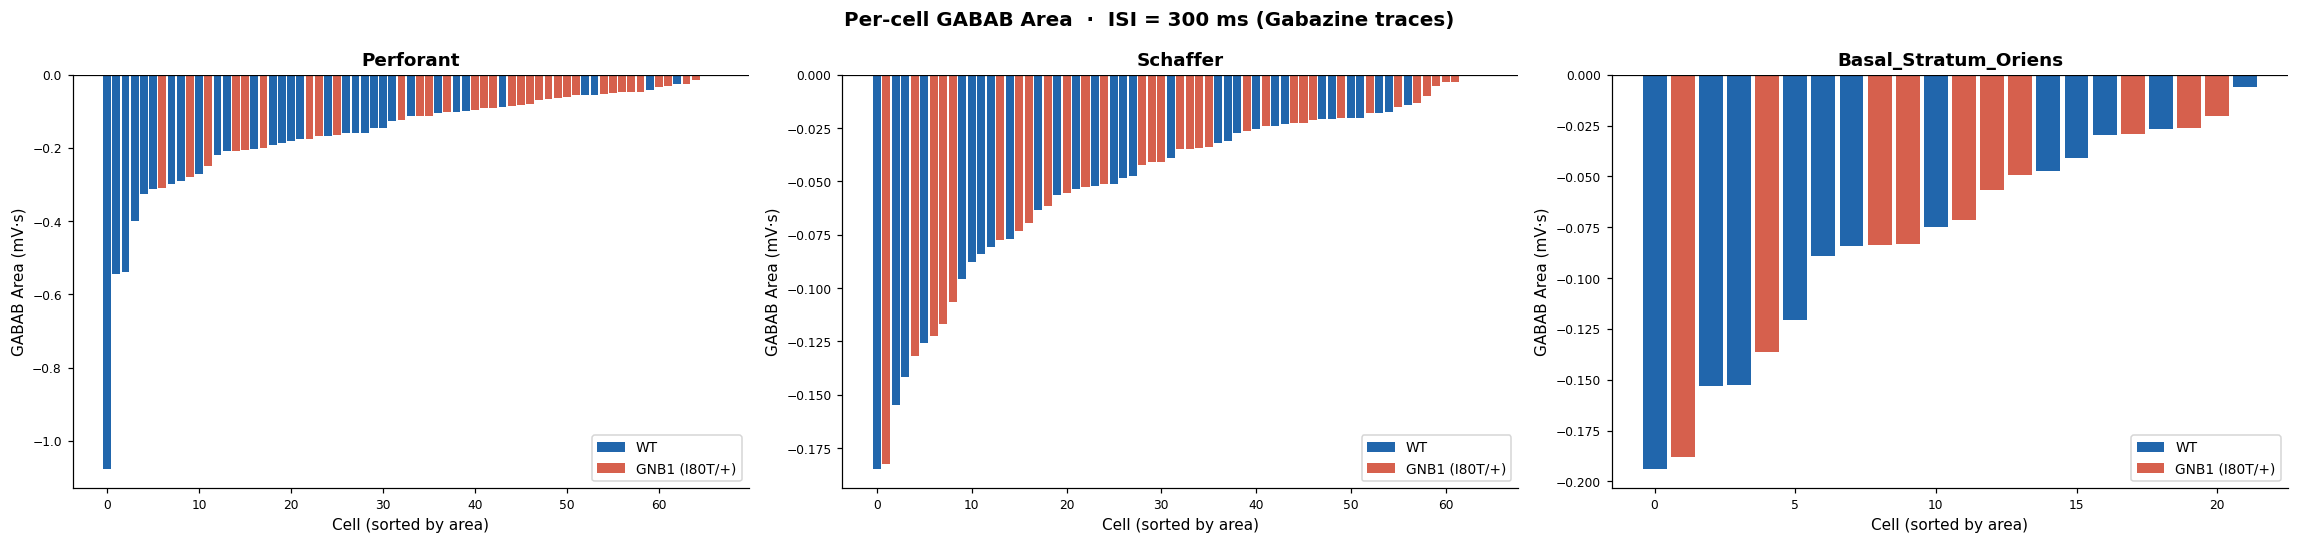

In [8]:
# ── Per-cell overview bar chart ───────────────────────────────────────────────

from matplotlib.patches import Patch

pathways_present = [p for p in ['Perforant', 'Schaffer', 'Basal_Stratum_Oriens']
                    if p in plot_df['Pathway'].values]

fig, axes = plt.subplots(
    1, len(pathways_present),
    figsize=(7 * len(pathways_present), 5),
    sharey=False
)
if len(pathways_present) == 1:
    axes = [axes]

legend_elements = [
    Patch(facecolor=WT_COLOR,   label='WT'),
    Patch(facecolor=GNB1_COLOR, label='GNB1 (I80T/+)'),
]

for ax, pathway in zip(axes, pathways_present):
    sub    = plot_df[plot_df['Pathway'] == pathway].sort_values('area')
    colors = [WT_COLOR if g == 'WT' else GNB1_COLOR for g in sub['Genotype']]
    ax.bar(range(len(sub)), sub['area'].values,
           color=colors, edgecolor='none', width=0.85)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(pathway, fontsize=12, fontweight='bold')
    ax.set_xlabel('Cell (sorted by area)', fontsize=10)
    ax.set_ylabel('GABAB Area (mV·s)', fontsize=10)
    ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

fig.suptitle(
    'Per-cell GABAB Area  ·  ISI = 300 ms (Gabazine traces)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()